### **Optimization Techniques in ANN: Calls backs and early stopping**

In [ ]:
# Step 1: Imports
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Step 2: Load and preprocess MNIST data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize inputs
x_train = x_train / 255.0
x_test = x_test / 255.0

# Flatten images: 28x28 → 784
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(y_train[0])

[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [ ]:
# Step 3: Build the ANN model
def create_ann_model():
    model = models.Sequential([
        layers.Dense(256, activation='relu', input_shape=(784,)),
        #layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        #layers.Dropout(0.3),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
# Step 5: Train the model_without optimization
model_1 = create_ann_model()

history1 = model_1.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    verbose=1
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8455 - loss: 0.5473 - val_accuracy: 0.9648 - val_loss: 0.1207
Epoch 2/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9645 - loss: 0.1184 - val_accuracy: 0.9712 - val_loss: 0.0951
Epoch 3/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.9755 - loss: 0.0779 - val_accuracy: 0.9763 - val_loss: 0.0804
Epoch 4/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9846 - loss: 0.0510 - val_accuracy: 0.9795 - val_loss: 0.0740
Epoch 5/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9892 - loss: 0.0367 - val_accuracy: 0.9775 - val_loss: 0.0762
Epoch 6/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9926 - loss: 0.0254 - val_accuracy: 0.9787 - val_loss: 0.0794
Epoch 7/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9930 - loss: 0.0208 - val_accuracy: 0.9795 - val_loss: 0.0780
Epoch 8/20
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9956 - loss: 0.0151 - val_accuracy: 0.

In [ ]:
# Step 6: Evaluate on test set
test_loss, test_acc = model_1.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.9795
Test Loss: 0.1062


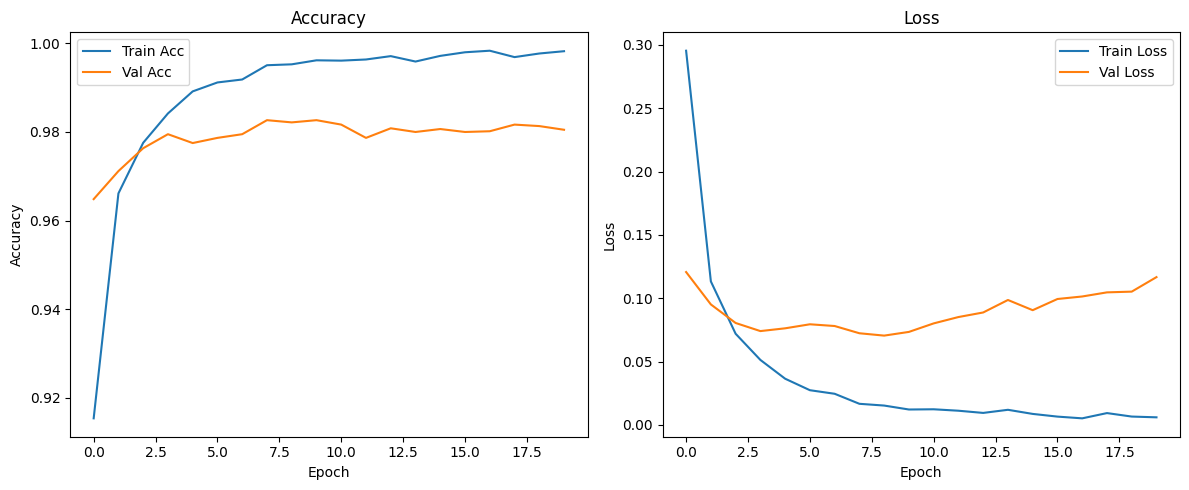

In [ ]:
# Step 7: Plot training history
def plot_history(history):
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history1)

### Basic Model Optimization with Callbacks (like early stopping & learning rate)

In [ ]:
# Step 4: Callbacks
## stops training when performance stops improving.
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# reduce learning rate at 0.5 rate
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-5, verbose=1)


In [ ]:
# Step 5: Train the model with callbacks
model_2 = create_ann_model()

history2 = model_2.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=2
)

Epoch 1/20
422/422 - 4s - 10ms/step - accuracy: 0.9154 - loss: 0.2903 - val_accuracy: 0.9648 - val_loss: 0.1225 - learning_rate: 1.0000e-03
Epoch 2/20
422/422 - 6s - 14ms/step - accuracy: 0.9669 - loss: 0.1100 - val_accuracy: 0.9738 - val_loss: 0.0868 - learning_rate: 1.0000e-03
Epoch 3/20
422/422 - 3s - 7ms/step - accuracy: 0.9781 - loss: 0.0717 - val_accuracy: 0.9755 - val_loss: 0.0822 - learning_rate: 1.0000e-03
Epoch 4/20
422/422 - 3s - 7ms/step - accuracy: 0.9844 - loss: 0.0510 - val_accuracy: 0.9755 - val_loss: 0.0839 - learning_rate: 1.0000e-03
Epoch 5/20
422/422 - 6s - 13ms/step - accuracy: 0.9881 - loss: 0.0386 - val_accuracy: 0.9780 - val_loss: 0.0757 - learning_rate: 1.0000e-03
Epoch 6/20
422/422 - 5s - 11ms/step - accuracy: 0.9906 - loss: 0.0298 - val_accuracy: 0.9767 - val_loss: 0.0777 - learning_rate: 1.0000e-03
Epoch 7/20
422/422 - 5s - 12ms/step - accuracy: 0.9926 - loss: 0.0232 - val_accuracy: 0.9782 - val_loss: 0.0788 - learning_rate: 1.0000e-03
Epoch 8/20
422/422 - 5

In [ ]:
test_loss, test_acc = model_2.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.9848
Test Loss: 0.0660


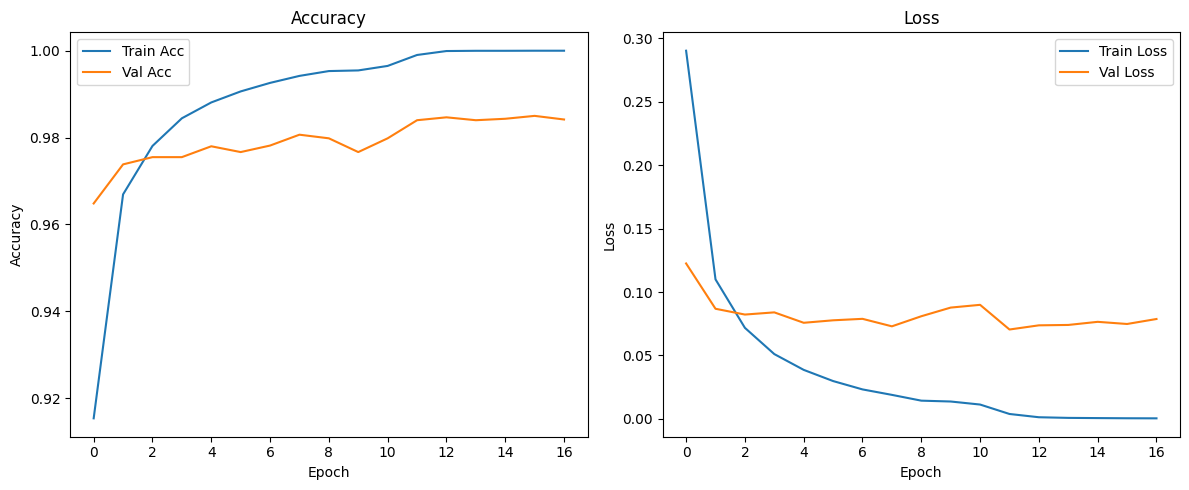

In [ ]:
plot_history(history2)

### Basic Model Optimization with Model Checkpoints Callback

In [ ]:
#Model Checkpointing: Model training will be saved in every epoch, we can backup and restore the partially trained model.

model_ckpt = ModelCheckpoint(
    filepath="best_model.h5",      # Save the checkpoints to best_model.h5 file during learning so that it can go back.
    monitor='val_accuracy',        # Save based on validation accuracy
    save_best_only=True,           # Only keep the best model
    save_weights_only=False,       # Save the entire model (not just weights)
    mode='max',                    # We want to maximize val_accuracy
    verbose=1                      # Log saving information
)

In [ ]:
#with Checkpoints
model_3 = create_ann_model()

history3 = model_3.fit(
    x_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    callbacks=[early_stop, reduce_lr,model_ckpt],
    verbose=2
)

Epoch 1/20

Epoch 1: val_accuracy improved from -inf to 0.96267, saving model to best_model.h5


422/422 - 4s - 10ms/step - accuracy: 0.9194 - loss: 0.2843 - val_accuracy: 0.9627 - val_loss: 0.1293 - learning_rate: 1.0000e-03
Epoch 2/20

Epoch 2: val_accuracy improved from 0.96267 to 0.97300, saving model to best_model.h5


422/422 - 3s - 8ms/step - accuracy: 0.9678 - loss: 0.1059 - val_accuracy: 0.9730 - val_loss: 0.0906 - learning_rate: 1.0000e-03
Epoch 3/20

Epoch 3: val_accuracy improved from 0.97300 to 0.97883, saving model to best_model.h5


422/422 - 3s - 8ms/step - accuracy: 0.9788 - loss: 0.0704 - val_accuracy: 0.9788 - val_loss: 0.0737 - learning_rate: 1.0000e-03
Epoch 4/20

Epoch 4: val_accuracy improved from 0.97883 to 0.98000, saving model to best_model.h5


422/422 - 5s - 11ms/step - accuracy: 0.9846 - loss: 0.0509 - val_accuracy: 0.9800 - val_loss: 0.0689 - learning_rate: 1.0000e-03
Epoch 5/20

Epoch 5: val_accuracy did not improve from 0.98000
422/422 - 7s - 16ms/step - accuracy: 0.9883 - loss: 0.0367 - val_accuracy: 0.9760 - val_loss: 0.0841 - learning_rate: 1.0000e-03
Epoch 6/20

Epoch 6: val_accuracy improved from 0.98000 to 0.98083, saving model to best_model.h5


422/422 - 4s - 9ms/step - accuracy: 0.9909 - loss: 0.0294 - val_accuracy: 0.9808 - val_loss: 0.0681 - learning_rate: 1.0000e-03
Epoch 7/20

Epoch 7: val_accuracy did not improve from 0.98083
422/422 - 5s - 12ms/step - accuracy: 0.9933 - loss: 0.0212 - val_accuracy: 0.9805 - val_loss: 0.0731 - learning_rate: 1.0000e-03
Epoch 8/20

Epoch 8: val_accuracy did not improve from 0.98083
422/422 - 4s - 9ms/step - accuracy: 0.9942 - loss: 0.0174 - val_accuracy: 0.9788 - val_loss: 0.0770 - learning_rate: 1.0000e-03
Epoch 9/20

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 9: val_accuracy did not improve from 0.98083
422/422 - 4s - 9ms/step - accuracy: 0.9954 - loss: 0.0143 - val_accuracy: 0.9803 - val_loss: 0.0799 - learning_rate: 1.0000e-03
Epoch 10/20

Epoch 10: val_accuracy improved from 0.98083 to 0.98317, saving model to best_model.h5


422/422 - 3s - 7ms/step - accuracy: 0.9988 - loss: 0.0052 - val_accuracy: 0.9832 - val_loss: 0.0743 - learning_rate: 5.0000e-04
Epoch 11/20

Epoch 11: val_accuracy improved from 0.98317 to 0.98367, saving model to best_model.h5


422/422 - 6s - 14ms/step - accuracy: 0.9999 - loss: 0.0019 - val_accuracy: 0.9837 - val_loss: 0.0761 - learning_rate: 5.0000e-04
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 6.


In [ ]:
test_loss, test_acc = model_3.evaluate(x_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.9804
Test Loss: 0.0655


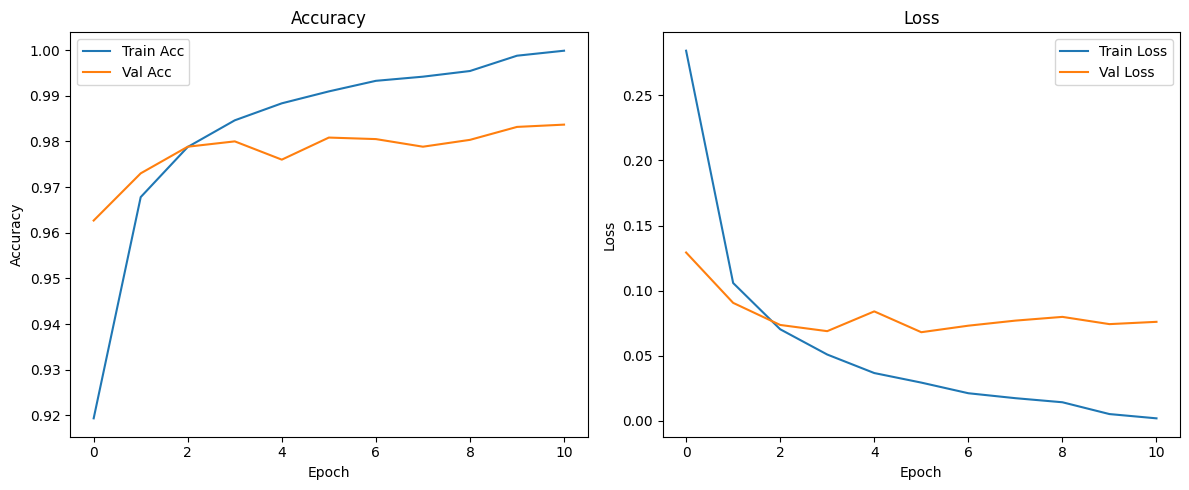

In [ ]:
plot_history(history3)

In [ ]:
#Load the best saved model later
best_model_restored = tf.keras.models.load_model('best_model.h5')

In [ ]:
pred = best_model_restored.predict(x_test)
y_pred = tf.argmax(pred, axis=1)

loss, acc = best_model_restored.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {acc:.4f}")

#Resume Training from the Saved Model
#Can also train the model further with more epochs

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9809 - loss: 0.0779
Test Loss: 0.0657, Test Accuracy: 0.9834


# Using scikit-learn pipeline

In [2]:
!pip install -U scikeras scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 88.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


===== Training Basic ANN =====
Epoch 1/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8675 - loss: 0.4501 - val_accuracy: 0.9710 - val_loss: 0.0999
Epoch 2/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9669 - loss: 0.1110 - val_accuracy: 0.9727 - val_loss: 0.0858
Epoch 3/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9773 - loss: 0.0731 - val_accuracy: 0.9765 - val_loss: 0.0828
Epoch 4/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9825 - loss: 0.0566 - val_accuracy: 0.9738 - val_loss: 0.0898
Epoch 5/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9864 - loss: 0.0408 - val_accuracy: 0.9790 - val_loss: 0.0775
Epoch 6/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9906 - loss: 0.0303 - val_accuracy: 0.9767 - val_loss: 0.0901
Epoch 7/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9919 - loss: 0.0254 - val_accuracy: 0.9778 - val_loss: 0.0896
Epoch 8/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - acc

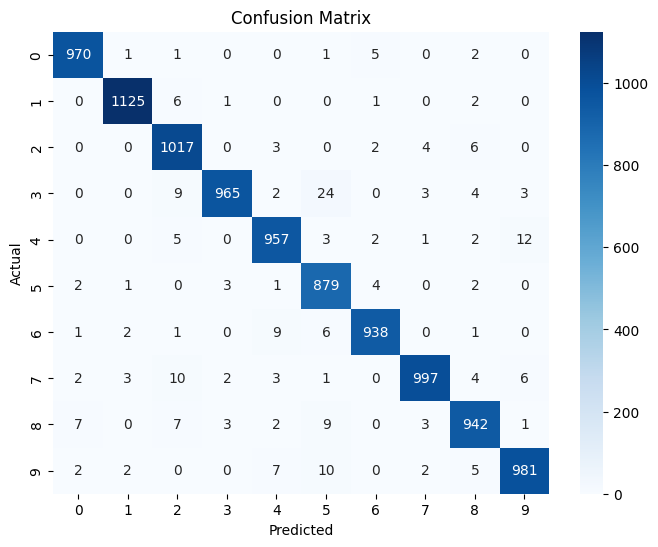

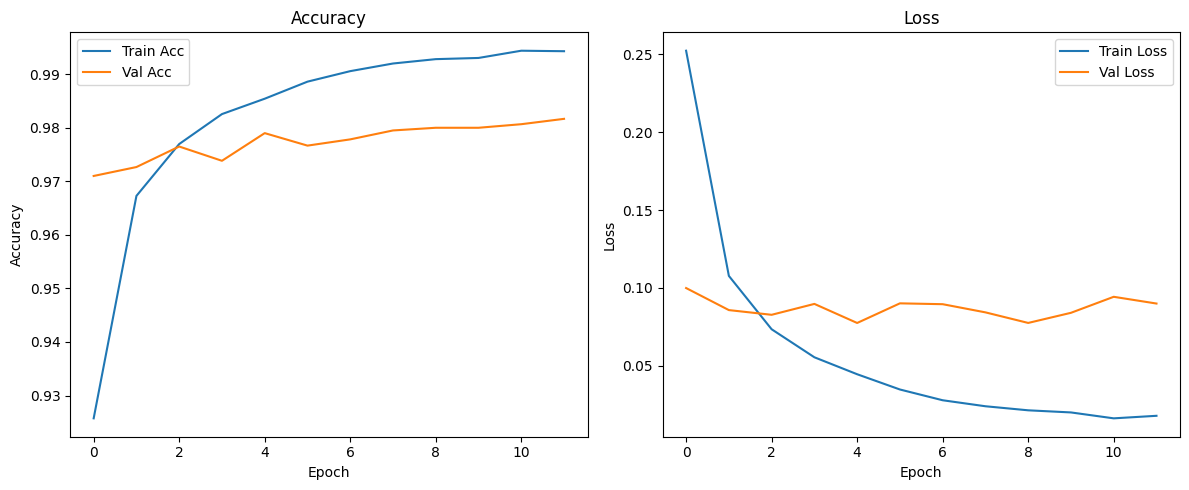

Test Accuracy: 0.9771
Test Loss: 0.0923
===== Training Basic ANN with Callback and Early Stopping =====
Epoch 1/12
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8839 - loss: 0.3859
Epoch 1: val_accuracy improved from -inf to 0.96400, saving model to best_model.h5


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8840 - loss: 0.3858 - val_accuracy: 0.9640 - val_loss: 0.1125 - learning_rate: 0.0010
Epoch 2/12
1668/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9694 - loss: 0.1007
Epoch 2: val_accuracy improved from 0.96400 to 0.97433, saving model to best_model.h5


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9695 - loss: 0.1007 - val_accuracy: 0.9743 - val_loss: 0.0833 - learning_rate: 0.0010
Epoch 3/12
1670/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9793 - loss: 0.0652
Epoch 3: val_accuracy improved from 0.97433 to 0.97933, saving model to best_model.h5


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9793 - loss: 0.0652 - val_accuracy: 0.9793 - val_loss: 0.0703 - learning_rate: 0.0010
Epoch 4/12
1682/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9848 - loss: 0.0479
Epoch 4: val_accuracy did not improve from 0.97933
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.9848 - loss: 0.0479 - val_accuracy: 0.9773 - val_loss: 0.0743 - learning_rate: 0.0010
Epoch 5/12
1671/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9871 - loss: 0.0392
Epoch 5: val_accuracy did not improve from 0.97933
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9871 - loss: 0.0392 - val_accuracy: 0.9750 - val_loss: 0.0945 - learning_rate: 0.0010
Epoch 6/12
1668/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9892 - loss: 0.0334
Epoch 6: val_accuracy improved from 0.97933 to 0.98100, saving model to best_model.h5


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9892 - loss: 0.0334 - val_accuracy: 0.9810 - val_loss: 0.0673 - learning_rate: 0.0010
Epoch 7/12
1669/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9918 - loss: 0.0249
Epoch 7: val_accuracy did not improve from 0.98100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9918 - loss: 0.0249 - val_accuracy: 0.9782 - val_loss: 0.0882 - learning_rate: 0.0010
Epoch 8/12
1686/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9931 - loss: 0.0221
Epoch 8: val_accuracy did not improve from 0.98100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9931 - loss: 0.0221 - val_accuracy: 0.9810 - val_loss: 0.0746 - learning_rate: 0.0010
Epoch 9/12
1670/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9936 - loss: 0.0194
Epoch 9: ReduceLROnPlateau reducing learning rate to 5.0000002374872565e-05.

Epoch 9: val_accuracy did not improve from 0.98100
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9936 - loss: 0.0194

1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9969 - loss: 0.0093 - val_accuracy: 0.9830 - val_loss: 0.0768 - learning_rate: 5.0000e-05
Epoch 11/12
1687/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9991 - loss: 0.0039
Epoch 11: val_accuracy improved from 0.98300 to 0.98333, saving model to best_model.h5


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9991 - loss: 0.0039 - val_accuracy: 0.9833 - val_loss: 0.0754 - learning_rate: 5.0000e-05
Epoch 11: early stopping
Restoring model weights from the end of the best epoch: 6.
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.98      0.98      0.98      1032
           3       0.98      0.98      0.98      1010
           4       0.98      0.98      0.98       982
           5       0.97      0.99      0.98       892
           6       0.98      0.99      0.98       958
           7       0.97      0.98      0.97      1028
           8       0.98      0.97      0.97       974
           9       0.98      0.96      0.97      1009

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



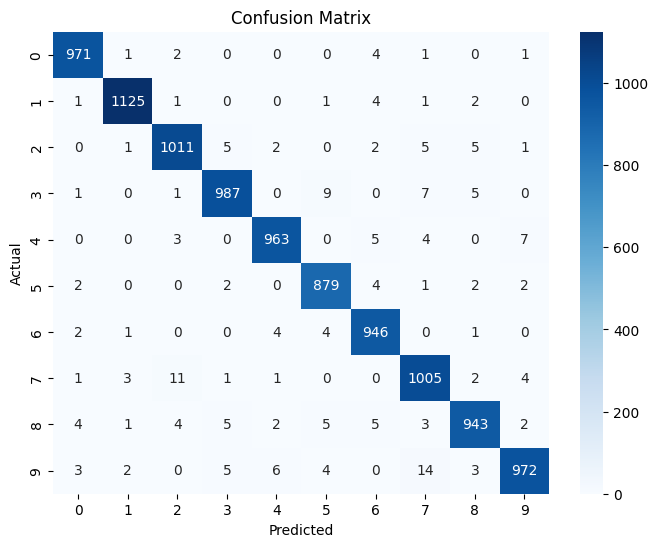

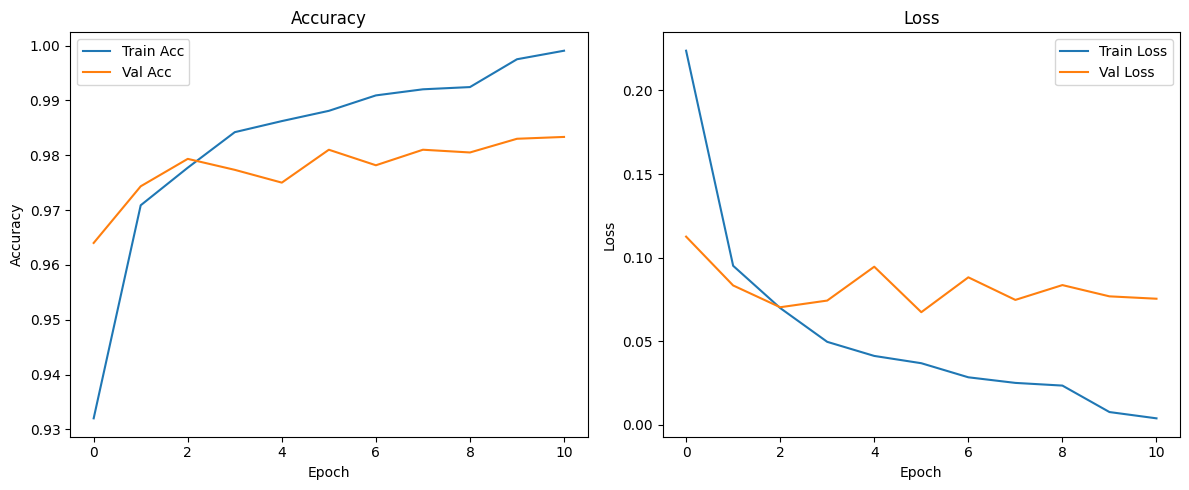

Test Accuracy: 0.9802
Test Loss: 0.0705


In [6]:
# Step 0: Imports
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import Sequential, Input, layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from scikeras.wrappers import KerasClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Step 1: Load & preprocess data
def load_mnist(flatten=True):
    (x_train, y_train), (x_test, y_test) = mnist.load_data()
    if flatten:
        x_train = x_train.reshape(-1, 28*28) # (60000, 784)
        x_test = x_test.reshape(-1, 28*28) # (10000, 784)
    return x_train, y_train, x_test, y_test

# Step 2: Define ANN models
def create_model_basic():
    model = Sequential([
        Input(shape=(784,)),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def create_model_deep():
    model = Sequential([
        Input(shape=(784,)),
        layers.Dense(256, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(64, activation="relu"),
        layers.Dense(10, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# Step 3: Build pipeline
def build_pipeline(model_fn, scaler=MinMaxScaler(), epochs=12, batch_size=32, callbacks=[]):
    keras_clf = KerasClassifier(model=model_fn,
                                epochs=epochs,
                                batch_size=batch_size,
                                validation_split=0.1,
                                callbacks=callbacks,
                                verbose=0,          # silence wrapper logs
                                fit__verbose=1      # ✅ pass verbose=1 to Keras .fit()
                                )
    pipeline = Pipeline([
        ("scaler", scaler),
        ("clf", keras_clf)
    ])
    return pipeline

# Step 4: Train, predict, evaluate, and plot history
def train_evaluate(pipeline, x_train, y_train, x_test, y_test):
    pipeline.fit(x_train, y_train)

    # Access history
    history = pipeline.named_steps["clf"].model_.history

    # Predictions
    y_pred = pipeline.predict(x_test)

    # Report
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # Plot training history
    plot_history(history)

    # Test evaluation
    test_loss, test_acc = pipeline.named_steps["clf"].model_.evaluate(
        pipeline.named_steps["scaler"].transform(x_test),
        y_test,
        verbose=0
    )
    print(f"Test Accuracy: {test_acc:.4f}")
    print(f"Test Loss: {test_loss:.4f}")

def plot_history(history):
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# ==========================
# Step 5: Run models
x_train, y_train, x_test, y_test = load_mnist()

callbacks=[]

# Model 1: Basic
pipeline_basic = build_pipeline(create_model_basic, epochs=12, callbacks=callbacks)
print("===== Training Basic ANN =====")
train_evaluate(pipeline_basic, x_train, y_train, x_test, y_test)

# Model 2: With Callback and Early Stopping
## stops training when performance stops improving.
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)

# reduce learning rate at 0.5 rate
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.05, patience=3, min_lr=1e-5, verbose=1)

#Model Checkpointing: Model training will be saved in every epoch, we can backup and restore the partially trained model.
model_ckpt = ModelCheckpoint(
    filepath="best_model.h5",      # Save the checkpoints to best_model.h5 file during learning so that it can go back.
    monitor='val_accuracy',        # Save based on validation accuracy
    save_best_only=True,           # Only keep the best model
    save_weights_only=False,       # Save the entire model (not just weights)
    mode='max',                    # We want to maximize val_accuracy
    verbose=1                      # Log saving information
)

callbacks=[early_stop, reduce_lr, model_ckpt]

pipeline_deep = build_pipeline(create_model_deep, epochs=12, callbacks=callbacks)
print("===== Training Deep ANN with Callback and Early Stopping =====")
train_evaluate(pipeline_deep, x_train, y_train, x_test, y_test)


